In [16]:
!pip install lifelines


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [17]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

from scipy.stats import mode
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df_metabric = pd.read_csv('data/Breast Cancer METABRIC.csv')

print(f'METABRIC Dataset Shape: {df_metabric.shape}')
print(f'METABRIC Dataset Memory Usage: {df_metabric.memory_usage().sum() / 1024 ** 2:.2f} MB')

METABRIC Dataset Shape: (2509, 34)
METABRIC Dataset Memory Usage: 0.65 MB


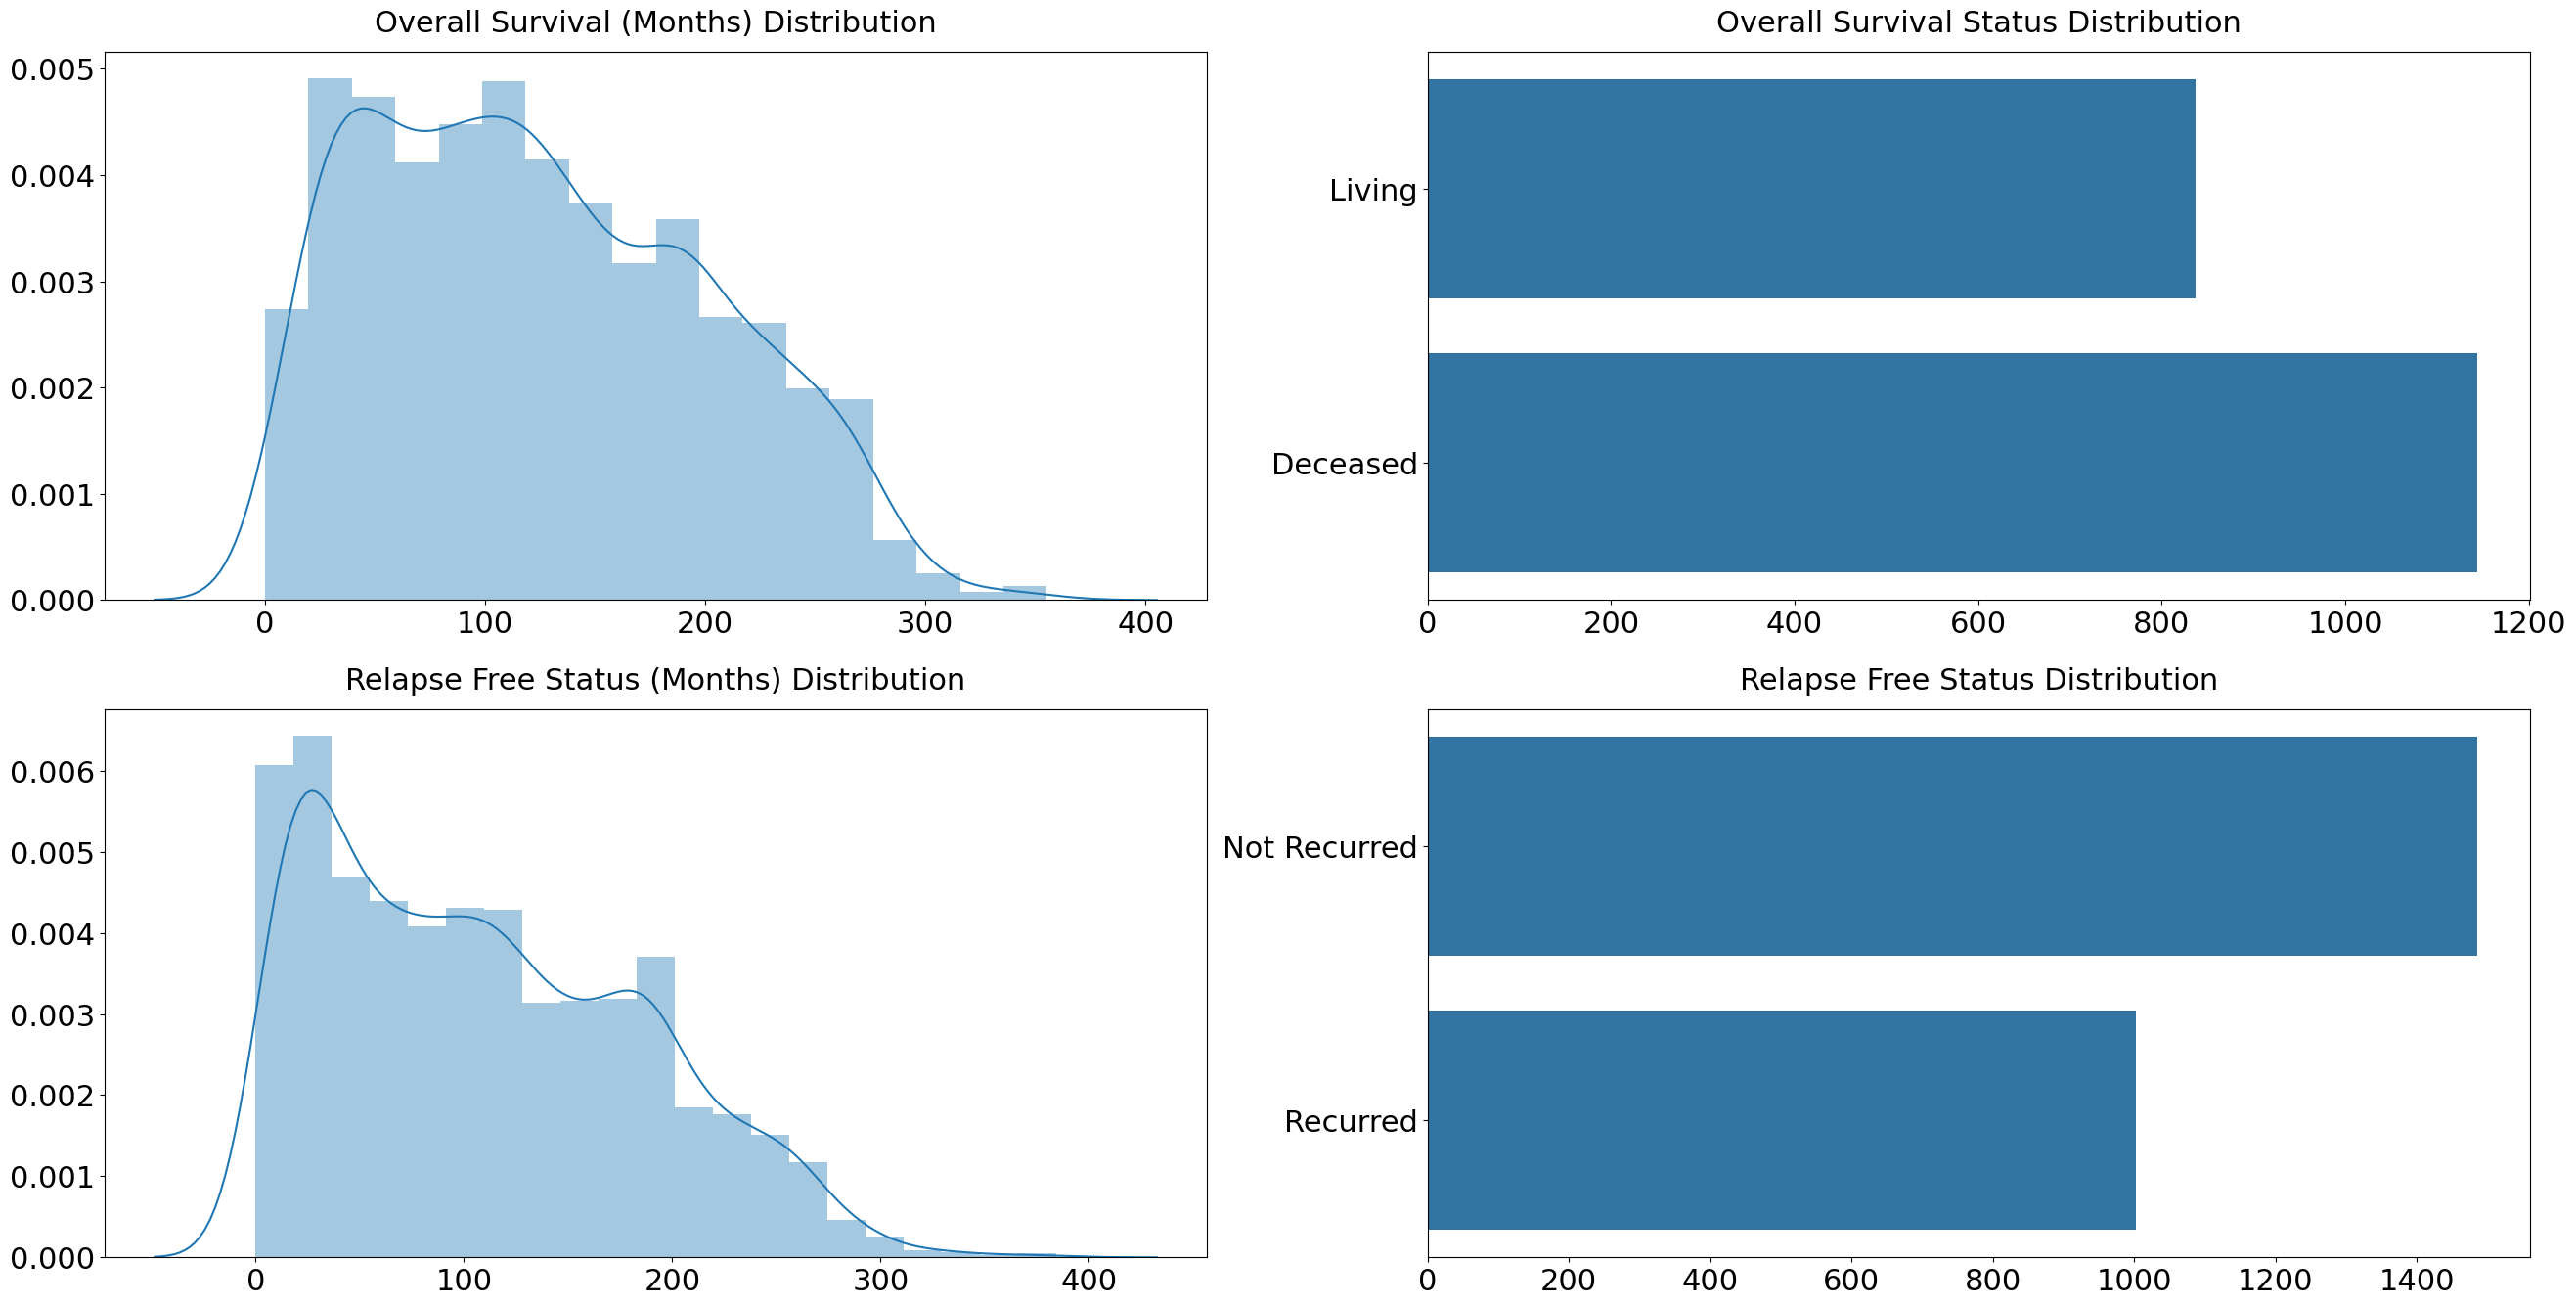

In [19]:
fig, axes = plt.subplots(figsize=(32, 16), ncols=2, nrows=2)

sns.distplot(df_metabric['Overall Survival (Months)'], ax=axes[0][0])
sns.countplot(df_metabric['Overall Survival Status'], ax=axes[0][1])
sns.distplot(df_metabric['Relapse Free Status (Months)'], ax=axes[1][0])
sns.countplot(df_metabric['Relapse Free Status'], ax=axes[1][1])

for i in range(2):
    for j in range(2):
        if i == 1 and j == 1:
            axes[i][j].tick_params(axis='x', labelsize=22)
        else:
            axes[i][j].tick_params(axis='x', labelsize=22)
        axes[i][j].tick_params(axis='y', labelsize=22)
        
        axes[i][j].set_xlabel('')
        axes[i][j].set_ylabel('')
        
axes[0][0].set_title('Overall Survival (Months) Distribution', size=22, pad=15)
axes[0][1].set_title('Overall Survival Status Distribution', size=22, pad=15)
axes[1][0].set_title('Relapse Free Status (Months) Distribution', size=22, pad=15)
axes[1][1].set_title('Relapse Free Status Distribution', size=22, pad=15)

plt.show()

### 1.4. Preprocessing and Cleaning

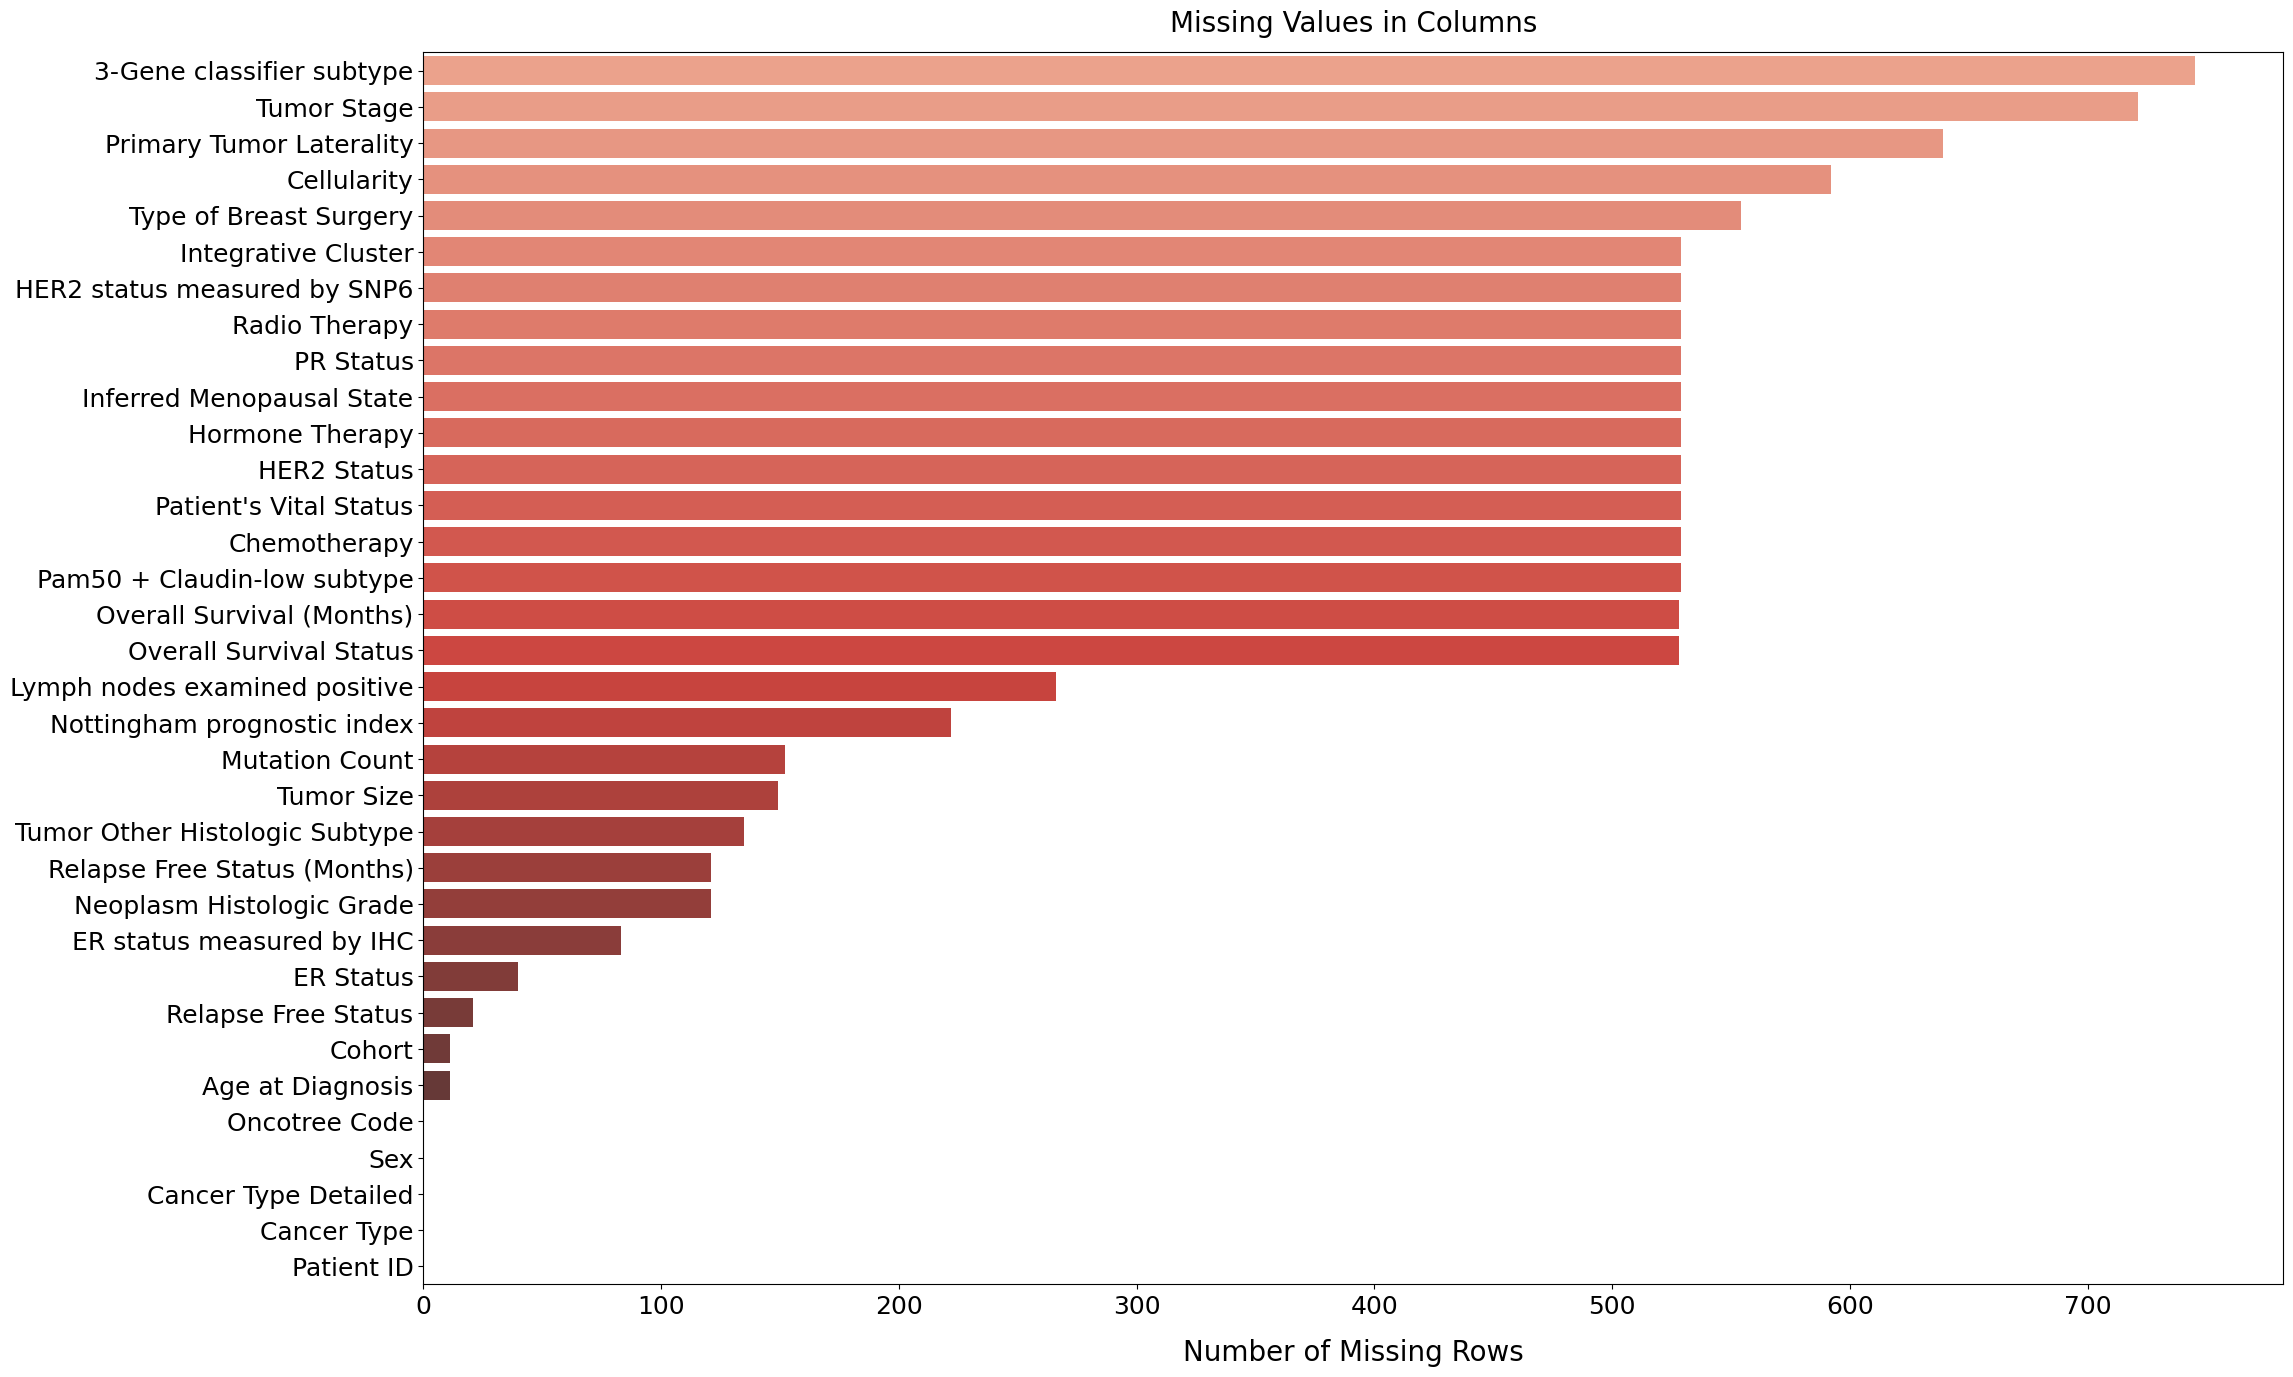

In [20]:
fig = plt.figure(figsize=(24, 16))

sns.barplot(x=df_metabric.isnull().sum().sort_values(ascending=False).values,
            y=df_metabric.isnull().sum().sort_values(ascending=False).index,
            palette='Reds_d')

plt.xlabel('Number of Missing Rows', size=20, labelpad=15)
plt.ylabel('')
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
plt.title('Missing Values in Columns', size=20, pad=15)

plt.show()

In [21]:
import pandas as pd
import numpy as np

# --- Helper functions ---

# Safe mode for categorical columns
def safe_mode(x, global_series=None):
    m = x.mode()
    if len(m) > 0:
        return x.fillna(m.iloc[0])
    elif global_series is not None:
        return x.fillna(global_series.mode().iloc[0])
    else:
        return x

# Safe mean for numeric columns
def safe_mean(x, global_series=None):
    if x.notna().any():
        return x.fillna(x.mean())
    elif global_series is not None:
        return x.fillna(global_series.mean())
    else:
        return x

# Safe median for numeric columns
def safe_median(x, global_series=None):
    if x.notna().any():
        return x.fillna(x.median())
    elif global_series is not None:
        return x.fillna(global_series.median())
    else:
        return x

# --- Imputation pipeline ---

# Event and duration columns
# DO NOT IMPUTE TARGETS — JUST DROP MISSING
df_metabric = df_metabric.dropna(subset=[
    'Overall Survival (Months)',
    'Overall Survival Status',
    'Relapse Free Status (Months)',
    'Relapse Free Status'
])

# ER, PR, HER2
df_metabric['ER status measured by IHC'] = safe_mode(df_metabric['ER status measured by IHC'])
df_metabric['ER Status'] = df_metabric.groupby('ER status measured by IHC')['ER Status']\
    .transform(lambda x: safe_mode(x, df_metabric['ER Status']))

df_metabric['HER2 status measured by SNP6'] = safe_mode(df_metabric['HER2 status measured by SNP6'])
df_metabric['HER2 Status'] = df_metabric.groupby('HER2 status measured by SNP6')['HER2 Status']\
    .transform(lambda x: safe_mode(x, df_metabric['HER2 Status']))

df_metabric['PR Status'] = df_metabric.groupby('Cancer Type Detailed')['PR Status']\
    .transform(lambda x: safe_mode(x, df_metabric['PR Status']))

# Therapy columns
for col in ['Chemotherapy','Hormone Therapy','Radio Therapy']:
    df_metabric[col] = df_metabric.groupby('Cancer Type Detailed')[col]\
        .transform(lambda x: safe_mode(x, df_metabric[col]))

# Numeric & other columns
df_metabric['Age at Diagnosis'] = df_metabric.groupby('Cancer Type Detailed')['Age at Diagnosis']\
    .transform(lambda x: safe_mean(x, df_metabric['Age at Diagnosis']))

df_metabric['Cohort'] = df_metabric.groupby('Cancer Type Detailed')['Cohort']\
    .transform(lambda x: safe_median(x, df_metabric['Cohort']))

df_metabric['Cellularity'] = df_metabric.groupby('Cancer Type Detailed')['Cellularity']\
    .transform(lambda x: safe_mode(x, df_metabric['Cellularity']))

df_metabric['Tumor Stage'] = df_metabric.groupby(['Cancer Type Detailed','Cellularity'])['Tumor Stage']\
    .transform(lambda x: safe_median(x, df_metabric['Tumor Stage']))

df_metabric['Tumor Stage'] = df_metabric.groupby('Cancer Type Detailed')['Tumor Stage']\
    .transform(lambda x: safe_median(x, df_metabric['Tumor Stage']))

df_metabric['Tumor Size'] = df_metabric.groupby(['Cancer Type Detailed','Tumor Stage'])['Tumor Size']\
    .transform(lambda x: safe_median(x, df_metabric['Tumor Size']))

df_metabric['Tumor Size'] = df_metabric.groupby('Cancer Type Detailed')['Tumor Size']\
    .transform(lambda x: safe_median(x, df_metabric['Tumor Size']))

df_metabric['Tumor Size'] = safe_mode(df_metabric['Tumor Size'])

# Categorical columns with fallback
for col in ['Neoplasm Histologic Grade','Primary Tumor Laterality','Tumor Other Histologic Subtype',
            'Mutation Count','Pam50 + Claudin-low subtype','Integrative Cluster',
            'Type of Breast Surgery','3-Gene classifier subtype']:
    df_metabric[col] = df_metabric.groupby('Cancer Type Detailed')[col]\
        .transform(lambda x: safe_mode(x, df_metabric[col]))

# Add default for any remaining specific cases
df_metabric['Tumor Other Histologic Subtype'] = df_metabric['Tumor Other Histologic Subtype'].fillna('Ductal/NST')

# Numeric columns
df_metabric['Nottingham prognostic index'] = df_metabric.groupby('Tumor Size')['Nottingham prognostic index']\
    .transform(lambda x: safe_median(x, df_metabric['Nottingham prognostic index']))

df_metabric['Nottingham prognostic index'] = df_metabric['Nottingham prognostic index']\
    .fillna(df_metabric['Nottingham prognostic index'].median())

df_metabric['Lymph nodes examined positive'] = df_metabric.groupby('Cancer Type Detailed')['Lymph nodes examined positive']\
    .transform(lambda x: safe_mode(x, df_metabric['Lymph nodes examined positive']))

df_metabric['Inferred Menopausal State'] = safe_mode(df_metabric['Inferred Menopausal State'])

# Drop unused column
df_metabric.drop(columns=["Patient's Vital Status"], inplace=True)

In [22]:
object_cols = ['Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed', 'Cellularity',
               'Chemotherapy', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'ER status measured by IHC',
               'ER Status', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype',
               'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality',
               'Oncotree Code', 'PR Status', 'Radio Therapy', 'Sex', '3-Gene classifier subtype']

for col in object_cols:
    df_metabric[col] = np.uint8(LabelEncoder().fit_transform(df_metabric[col]))
    
df_metabric['Overall Survival Status'] = np.uint8(df_metabric['Overall Survival Status'].map({'Living': 0, 'Deceased': 1}))
df_metabric['Relapse Free Status'] = np.uint8(df_metabric['Relapse Free Status'].map({'Not Recurred': 0, 'Recurred': 1}))

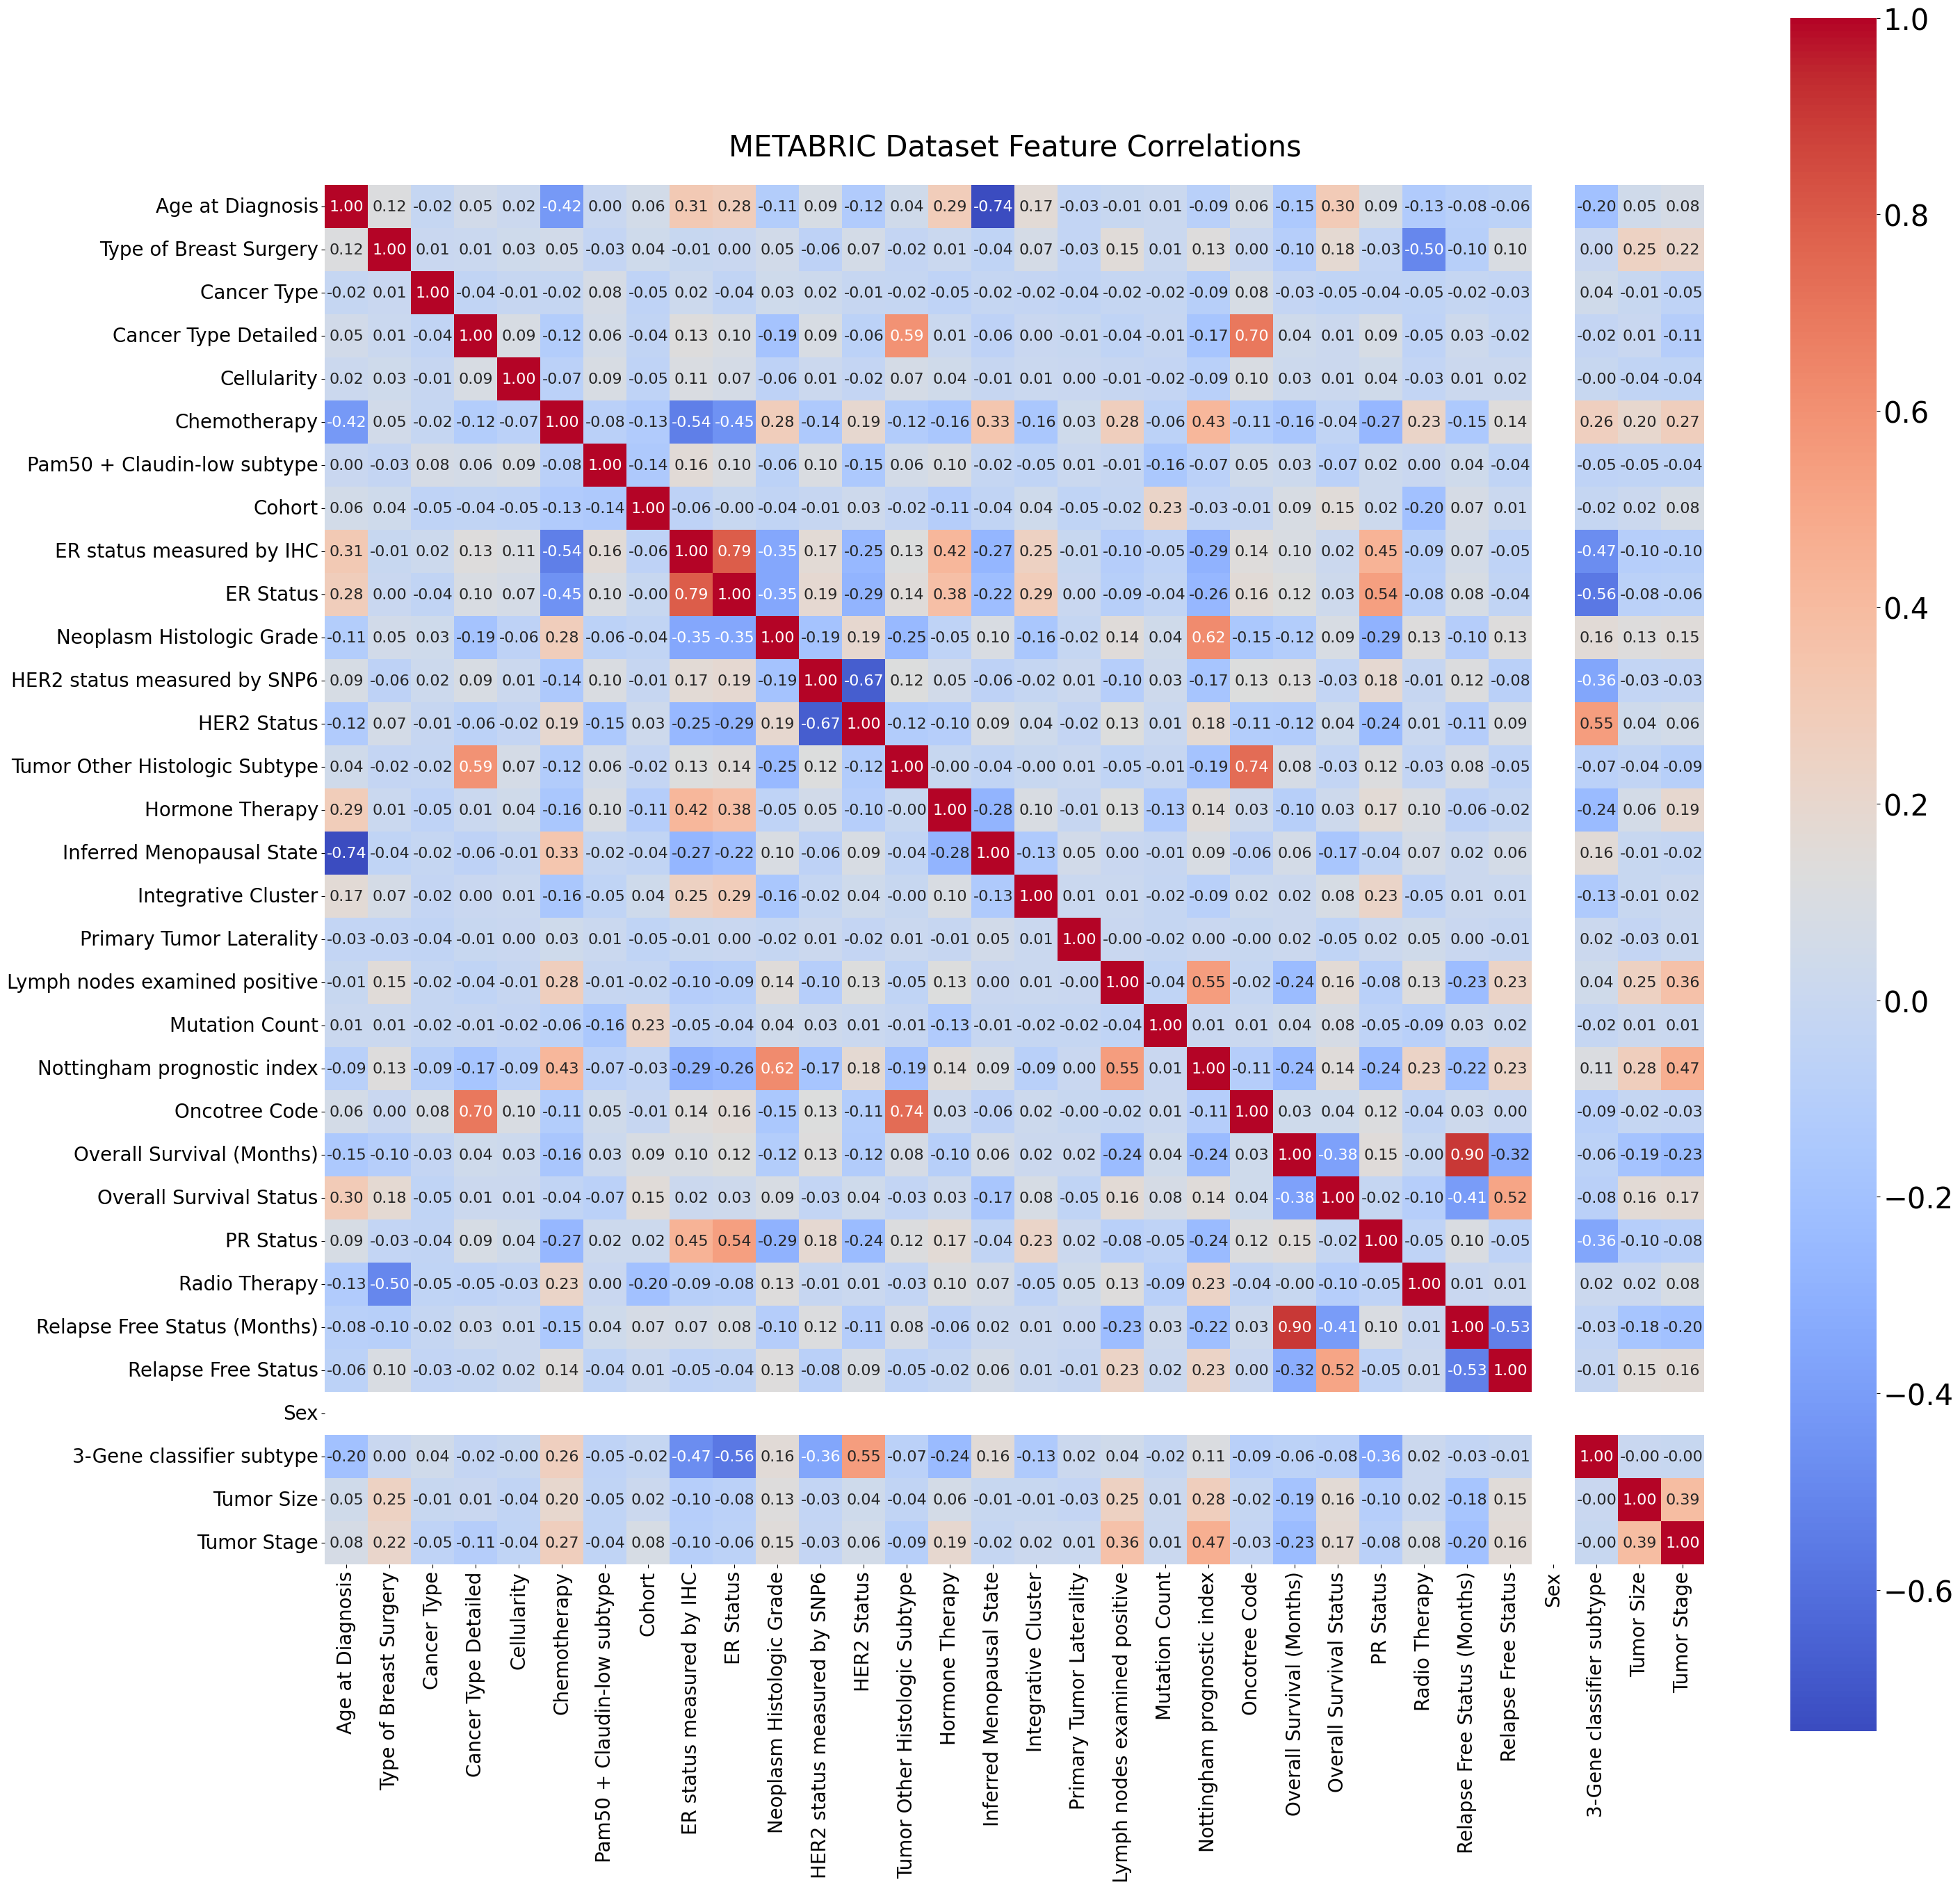

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df_metabric.select_dtypes(include=np.number)

fig = plt.figure(figsize=(32, 32), dpi=100)

ax = sns.heatmap(
    numeric_df.corr(), 
    annot=True, 
    square=True, 
    cmap='coolwarm', 
    annot_kws={'size': 16},  
    fmt='.2f'
)

# Colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=30)

# Tick labels
plt.tick_params(axis='x', labelsize=20, rotation=90)
plt.tick_params(axis='y', labelsize=20, rotation=0)

plt.title('METABRIC Dataset Feature Correlations', size=30, pad=30)
plt.show()

In [24]:
df_metabric.drop(columns=['Integrative Cluster'], inplace=True)

### 3.1. Right Censoring

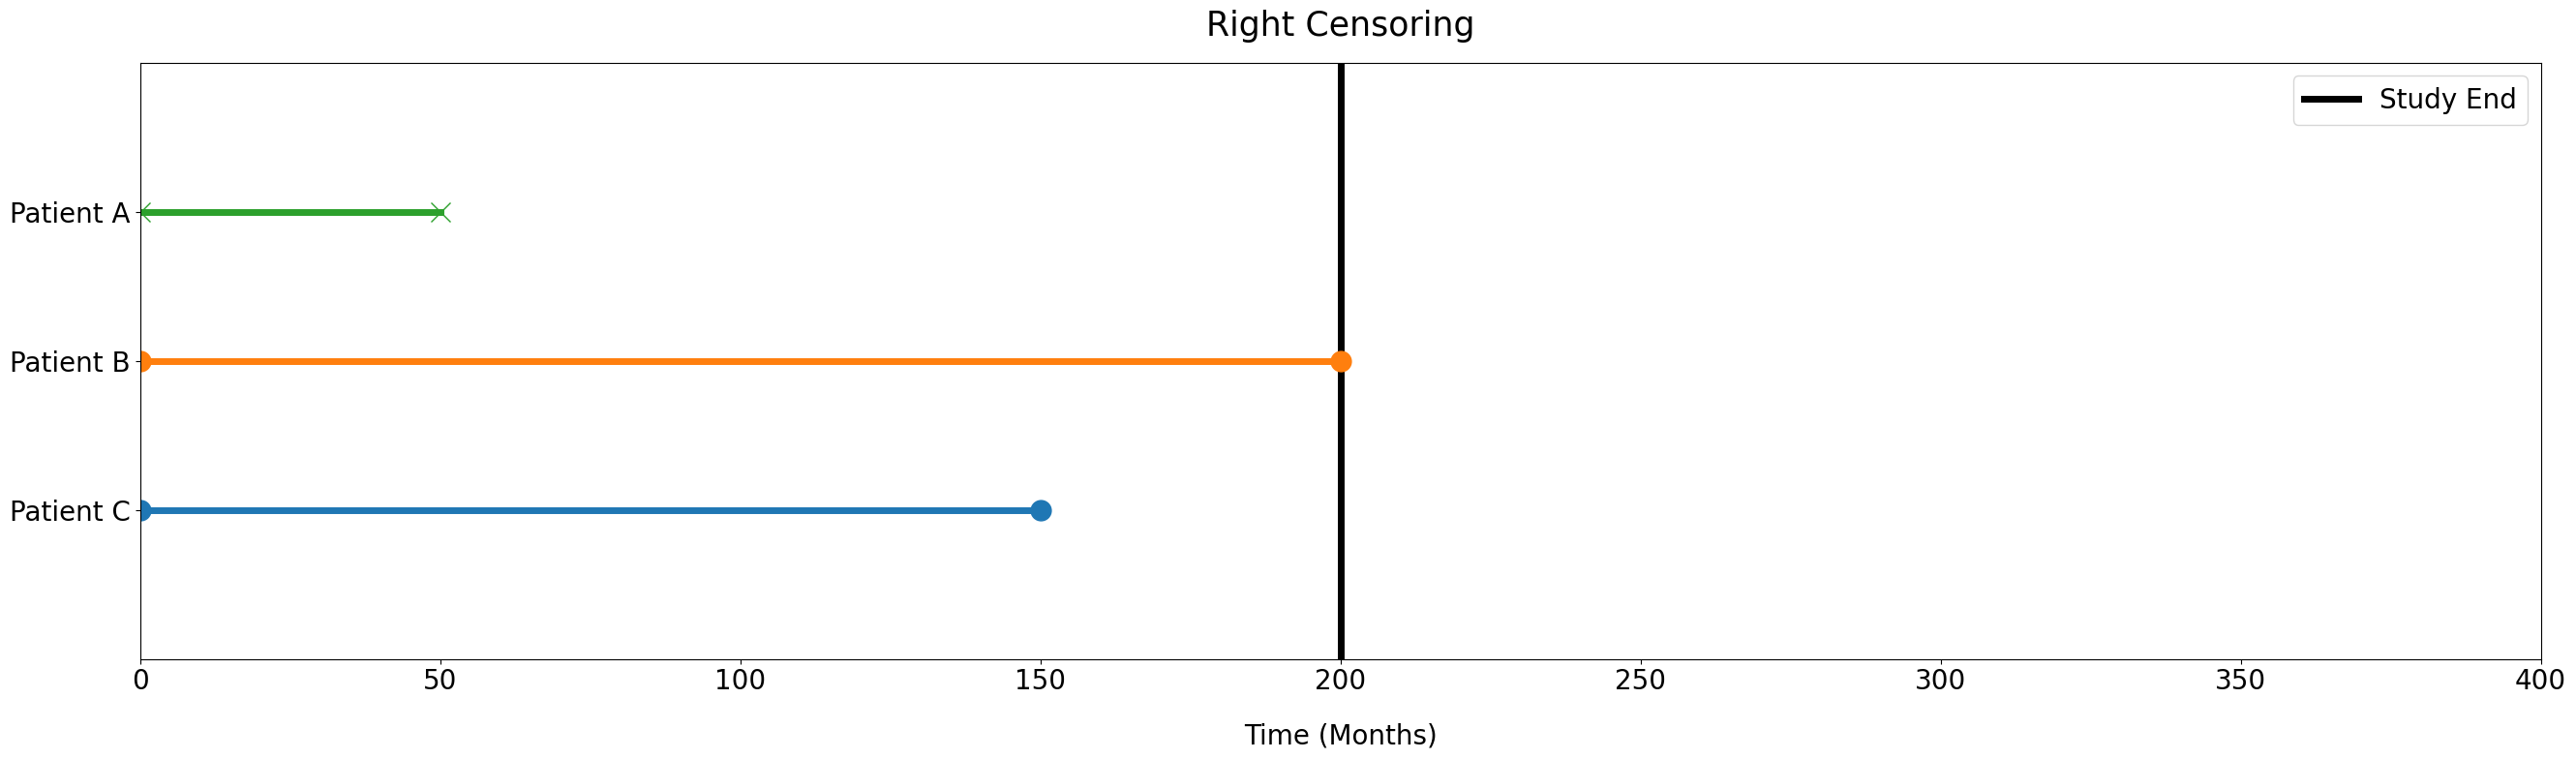

In [25]:
fig = plt.figure(figsize=(32, 8))

plt.xlim(0, 400), plt.ylim(0, 4)
plt.axvline(200, color='black', label='Study End', linewidth=5)
plt.plot([0, 150], [1, 1], marker='o', markersize=15, linewidth=5)
plt.plot([0, 200], [2, 2], marker='o', markersize=15, linewidth=5)
plt.plot([0, 50], [3, 3], marker='x', markersize=15, linewidth=5)

plt.xlabel('Time (Months)', size=20, labelpad=20)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.yticks([1, 2, 3], ['Patient C', 'Patient B', 'Patient A'])
plt.legend(prop={'size': 20})
plt.title('Right Censoring', size=25, pad=20)

plt.show()

## 4. Evaluation

In [26]:
def time_dependent_roc_auc_score(y_true, y_pred, survival_times):

    time_dependent_y_true = pd.DataFrame(
        data=np.zeros((y_pred.shape[0], y_pred.shape[1])),
        index=y_true.index,
        columns=y_pred.columns,
        dtype=np.uint8
    )

    # ✅ FIXED LOOP
    for i, time in enumerate(y_pred.columns):
        time_dependent_y_true.iloc[:, i] = ((y_true == 1) & (survival_times <= time)).astype(np.uint8)

    scores = {}
    for time in y_pred.columns:
        # ✅ FIXED: use event probability
        score = np.round(roc_auc_score(time_dependent_y_true[time], 1 - y_pred[time]), 6)
        scores[int(time)] = score

    return scores


In [27]:
df_train, df_test = train_test_split(df_metabric,
                                     test_size=0.2,
                                     stratify=df_metabric['Cancer Type Detailed'],
                                     shuffle=True,
                                     random_state=0)

df_train.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
for fold, (_, val_idx) in enumerate(skf.split(df_train, df_train['Cancer Type Detailed']), 1):
    df_train.loc[val_idx, 'fold'] = fold

df_train['fold'] = df_train['fold'].astype(np.uint8)

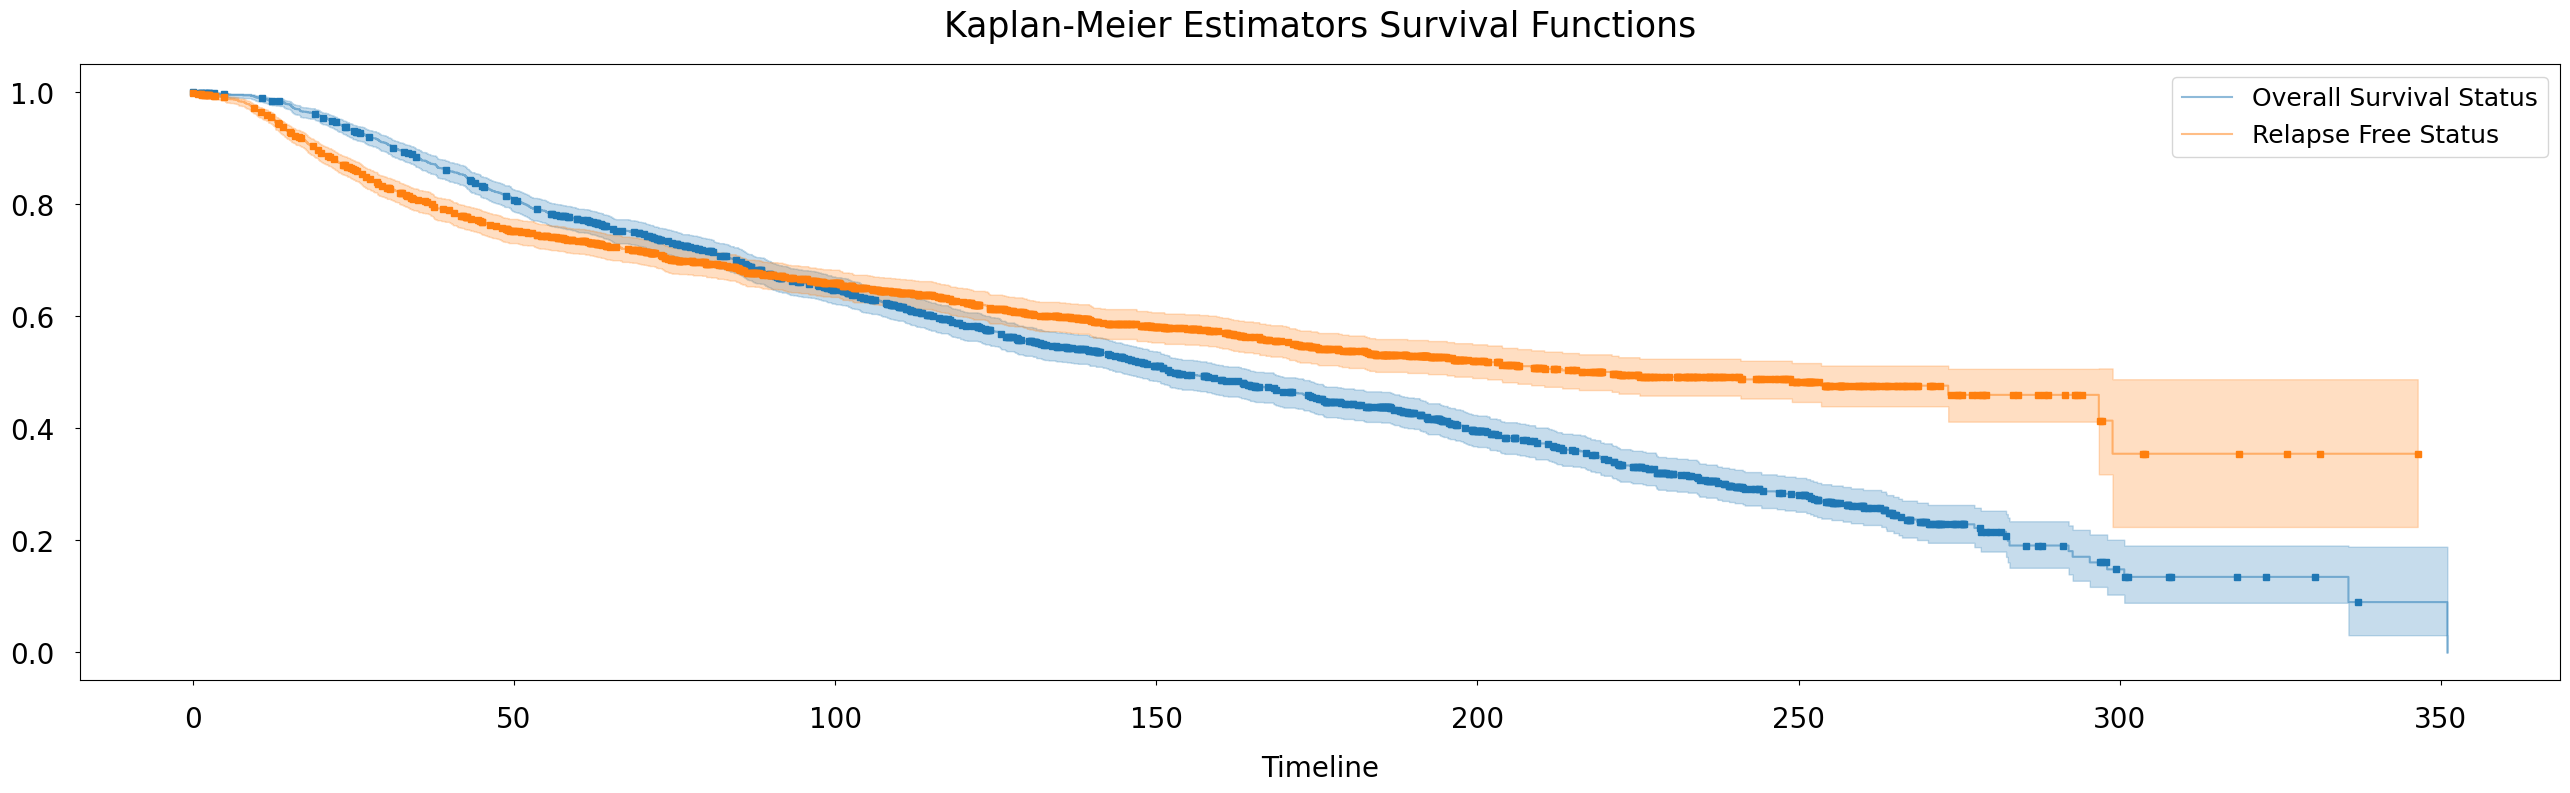

In [28]:
fig = plt.figure(figsize=(32, 8))

for time, event in zip(['Overall Survival (Months)', 'Relapse Free Status (Months)'], ['Overall Survival Status', 'Relapse Free Status']):
       
    T, E = df_train[time], df_train[event]
    kmf = KaplanMeierFitter()
    kmf.fit(T, E)
    kmf.plot(label=event, alpha=0.5, show_censors=True, censor_styles={'ms': 4, 'marker': 's'})
    
plt.xlabel('Timeline', size=20, labelpad=15)
plt.ylabel('')
plt.tick_params(axis='x', labelsize=20, pad=15)
plt.tick_params(axis='y', labelsize=20, pad=15)
plt.legend(prop={'size': 18})
plt.title('Kaplan-Meier Estimators Survival Functions', size=25, pad=20)

plt.show()

In [29]:
evaluation_times = [12, 24, 36]

for time, event in zip(['Overall Survival (Months)', 'Relapse Free Status (Months)'], ['Overall Survival Status', 'Relapse Free Status']):
    
    df_oof_survival_function = pd.DataFrame(data=np.zeros((df_train.shape[0], len(evaluation_times))),
                                                index=df_train.index,
                                                columns=evaluation_times)
    df_test_survival_function = pd.DataFrame(data=np.zeros((df_test.shape[0], len(evaluation_times))),
                                             index=df_test.index,
                                             columns=evaluation_times)
    
    for fold in sorted(df_train['fold'].unique()):
                    
        trn_idx, val_idx = df_train.loc[df_train['fold'] != fold].index, df_train.loc[df_train['fold'] == fold].index       
        T_trn, E_trn = df_train.loc[trn_idx, time], df_train.loc[trn_idx, event]
        T_val, E_val = df_train.loc[val_idx, time], df_train.loc[val_idx, event]
        kmf = KaplanMeierFitter()
        kmf.fit(T_trn, E_trn)
        
        survival_function = kmf.predict(times=evaluation_times)        
        val_survival_function = pd.DataFrame(
    np.repeat(survival_function.values.reshape(1, -1), len(val_idx), axis=0),
    index=val_idx,
    columns=evaluation_times
)     
        df_oof_survival_function.loc[val_idx, :] = val_survival_function.values        
        test_survival_function = pd.DataFrame(
    np.repeat(survival_function.values.reshape(1, -1), df_test.shape[0], axis=0),
    index=df_test.index,
    columns=evaluation_times
)
        df_test_survival_function += (test_survival_function.values / n_splits)

        val_auc = time_dependent_roc_auc_score(df_train.loc[val_idx, event], val_survival_function, df_train.loc[val_idx, time])
        print(f'Fold {fold} ({time}) - ROC AUC Scores {val_auc}')
        
    oof_auc = time_dependent_roc_auc_score(df_train[event], df_oof_survival_function, df_train[time])
    test_auc = time_dependent_roc_auc_score(df_test[event], df_test_survival_function, df_test[time])
    print(f'{"-" * 30}\nKaplan Meier Estimate {time} OOF AUC: {oof_auc}')
    print(f'Kaplan-Meier Estimate {time} Test AUC: {test_auc}\n{"-" * 30}\n')

Fold 1 (Overall Survival (Months)) - ROC AUC Scores {12: np.float64(0.5), 24: np.float64(0.5), 36: np.float64(0.5)}
Fold 2 (Overall Survival (Months)) - ROC AUC Scores {12: np.float64(0.5), 24: np.float64(0.5), 36: np.float64(0.5)}
Fold 3 (Overall Survival (Months)) - ROC AUC Scores {12: np.float64(0.5), 24: np.float64(0.5), 36: np.float64(0.5)}
Fold 4 (Overall Survival (Months)) - ROC AUC Scores {12: np.float64(0.5), 24: np.float64(0.5), 36: np.float64(0.5)}
Fold 5 (Overall Survival (Months)) - ROC AUC Scores {12: np.float64(0.5), 24: np.float64(0.5), 36: np.float64(0.5)}
------------------------------
Kaplan Meier Estimate Overall Survival (Months) OOF AUC: {12: np.float64(0.429128), 24: np.float64(0.427133), 36: np.float64(0.431509)}
Kaplan-Meier Estimate Overall Survival (Months) Test AUC: {12: np.float64(0.5), 24: np.float64(0.5), 36: np.float64(0.5)}
------------------------------

Fold 1 (Relapse Free Status (Months)) - ROC AUC Scores {12: np.float64(0.5), 24: np.float64(0.5), 3

In [30]:
evaluation_times = [12, 24, 36]
os_covariates = ['Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type',
                 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy',
                 'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC',
                 'ER Status', 'Neoplasm Histologic Grade', 'HER2 status measured by SNP6',
                 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy',
                 'Inferred Menopausal State', 'Primary Tumor Laterality', 'Lymph nodes examined positive',
                 'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code', 'PR Status',
                 '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage']
rfs_covariates = ['Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type',
                 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy',
                 'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC',
                 'ER Status', 'Neoplasm Histologic Grade', 'HER2 status measured by SNP6',
                 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy',
                 'Inferred Menopausal State', 'Primary Tumor Laterality', 'Lymph nodes examined positive',
                 'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code', 'PR Status',
                 '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage']

for time, event, covariates in zip(['Overall Survival (Months)', 'Relapse Free Status (Months)'],
                                   ['Overall Survival Status', 'Relapse Free Status'],
                                   [os_covariates, rfs_covariates]):
    
    df_oof_survival_function = pd.DataFrame(data=np.zeros((df_train.shape[0], len(evaluation_times))), index=df_train.index, columns=evaluation_times)
    df_oof_hazard_rates = pd.DataFrame(data=np.zeros(df_train.shape[0]), index=df_train.index, columns=['Partial Hazard Rates'])
    df_test_survival_function = pd.DataFrame(data=np.zeros((df_test.shape[0], len(evaluation_times))), index=df_test.index, columns=evaluation_times)
    df_test_hazard_rates = pd.DataFrame(data=np.zeros(df_test.shape[0]), index=df_test.index, columns=['Partial Hazard Rates'])
    
    for fold in sorted(df_train['fold'].unique()):
                    
        trn_idx, val_idx = df_train.loc[df_train['fold'] != fold].index, df_train.loc[df_train['fold'] == fold].index       
        trn = df_train.loc[trn_idx, covariates + [time, event]]
        val = df_train.loc[val_idx, covariates]
        
        cph = CoxPHFitter(baseline_estimation_method='breslow',
                          n_baseline_knots=4,
                          penalizer=1e-2)
        cph.fit(trn, duration_col=time, event_col=event)
        
        val_survival_function = cph.predict_survival_function(val, times=evaluation_times).T
        test_survival_function = cph.predict_survival_function(df_test[covariates], times=evaluation_times).T
        df_oof_survival_function.loc[val_idx, :] = val_survival_function.values
        df_test_survival_function += (test_survival_function.values / n_splits)
        
        df_oof_hazard_rates.loc[val_idx, 'Partial Hazard Rates'] = -cph.predict_partial_hazard(val)
        df_test_hazard_rates['Partial Hazard Rates'] += -cph.predict_partial_hazard(df_test[covariates])

        val_auc = time_dependent_roc_auc_score(df_train.loc[val_idx, event], val_survival_function, df_train.loc[val_idx, time])
        val_ci = concordance_index(df_train.loc[val_idx, time], df_oof_hazard_rates.loc[val_idx, 'Partial Hazard Rates'], df_train.loc[val_idx, event])
        print(f'Fold {fold} ({time}) - ROC AUC Scores {val_auc} - Concordance Index: {val_ci:.6}')
        
    oof_auc = time_dependent_roc_auc_score(df_train[event], df_oof_survival_function, df_train[time])
    oof_ci = concordance_index(df_train[time], df_oof_hazard_rates['Partial Hazard Rates'], df_train[event])
    test_auc = time_dependent_roc_auc_score(df_test[event], df_test_survival_function, df_test[time])
    test_ci = concordance_index(df_test[time], df_test_hazard_rates['Partial Hazard Rates'], df_test[event])
    print(f'{"-" * 30}\nCox Proportional Hazards Model {time} - OOF ROC AUC Scores: {oof_auc} - Concordance Index: {oof_ci:.6}')
    print(f'Cox Proportional Hazards Model {time} - Test ROC AUC Scores: {test_auc} - Concordance Index: {test_ci:.6}\n{"-" * 30}\n')


Fold 1 (Overall Survival (Months)) - ROC AUC Scores {12: np.float64(0.858333), 24: np.float64(0.748124), 36: np.float64(0.73521)} - Concordance Index: 0.696677
Fold 2 (Overall Survival (Months)) - ROC AUC Scores {12: np.float64(0.669841), 24: np.float64(0.710133), 36: np.float64(0.728881)} - Concordance Index: 0.666356
Fold 3 (Overall Survival (Months)) - ROC AUC Scores {12: np.float64(0.701923), 24: np.float64(0.723729), 36: np.float64(0.744036)} - Concordance Index: 0.678149
Fold 4 (Overall Survival (Months)) - ROC AUC Scores {12: np.float64(0.797436), 24: np.float64(0.652546), 36: np.float64(0.619622)} - Concordance Index: 0.678382
Fold 5 (Overall Survival (Months)) - ROC AUC Scores {12: np.float64(0.677419), 24: np.float64(0.724498), 36: np.float64(0.750297)} - Concordance Index: 0.695292
------------------------------
Cox Proportional Hazards Model Overall Survival (Months) - OOF ROC AUC Scores: {12: np.float64(0.744033), 24: np.float64(0.705438), 36: np.float64(0.712055)} - Conco